<a href="https://colab.research.google.com/github/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%204/Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)

In [2]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.1 MB/s eta 0:00:00


In [55]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import missingno as msno
from category_encoders import TargetEncoder
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Ellipse
import category_encoders as ce
from statsmodels.tools.eval_measures import rmse
import seaborn as sns

In [5]:
cvitals_url = 'https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Assignment%204/OmniCare_Clinical_Vitals.csv'
telemetry_url = 'https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Assignment%204/OmniCare_Telemetry_Data.csv'

clinical = pd.read_csv(cvitals_url)
telemetry = pd.read_csv(telemetry_url)

df = pd.merge(clinical, telemetry, on='Patient_ID')

df.head()

,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,High_Deductible_Insurance_Plan,Inpatient_Admission_Rate,Continuous_Heart_Rate,Primary_Diagnosis_Code,Clinic_Capacity_Percentage,Time_of_Day_Index,Procedure_Cost_USD
0,1000,177.5,66.3,21.06,110.0,75.0,1,0.341,76.9,J86.381,0.63,19.4,1635.84
1,1001,167.9,57.5,20.39,115.0,79.0,0,0.213,79.6,M29.789,0.71,19.3,1355.77
2,1002,179.7,57.4,17.77,111.0,77.0,0,0.166,92.3,E49.618,0.76,16.8,1189.19
3,1003,192.8,80.9,21.76,122.0,88.0,1,0.143,79.3,E66.244,0.52,11.5,1250.93
4,1004,166.5,65.7,23.70,138.0,89.0,0,0.219,75.9,J45.553,0.65,20.2,1986.34


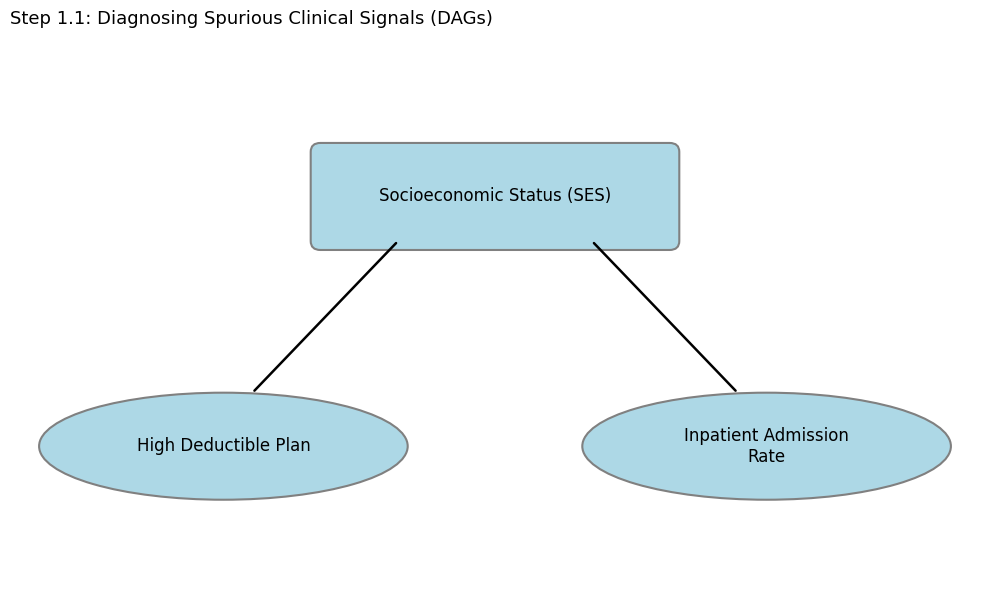

In [10]:
from matplotlib.patches import FancyBboxPatch, Ellipse

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

box = FancyBboxPatch((3.2, 3.8), 3.6, 1.0,
                     boxstyle="round,pad=0.1",
                     linewidth=1.5, edgecolor='gray',
                     facecolor='lightblue')
ax.add_patch(box)
ax.text(5.0, 4.3, "Socioeconomic Status (SES)",
        ha='center', va='center', fontsize=12)

ell_left = Ellipse((2.2, 1.5), width=3.8, height=1.2,
                   linewidth=1.5, edgecolor='gray', facecolor='lightblue')
ax.add_patch(ell_left)
ax.text(2.2, 1.5, "High Deductible Plan",
        ha='center', va='center', fontsize=12)

ell_right = Ellipse((7.8, 1.5), width=3.8, height=1.2,
                    linewidth=1.5, edgecolor='gray', facecolor='lightblue')
ax.add_patch(ell_right)
ax.text(7.8, 1.5, "Inpatient Admission\nRate",
        ha='center', va='center', fontsize=12)

ax.annotate("", xy=(2.5, 2.1), xytext=(4.0, 3.8),
            arrowprops=dict(arrowstyle="-", color='black', lw=1.8))
ax.annotate("", xy=(7.5, 2.1), xytext=(6.0, 3.8),
            arrowprops=dict(arrowstyle="-", color='black', lw=1.8))

ax.set_title("Step 1.1: Diagnosing Spurious Clinical Signals (DAGs)",
             fontsize=13, pad=15, loc='left')
plt.tight_layout()
plt.show()

The omitted confounder is Socioeconomic Status. Lower income patients are more likely to enroll in high deductible plans due to cheaper premiums, while also receiving less preventative care and visiting doctors less frequently, both of which drive up inpatient admission rates. Since SES influences both high deductible insurance plan and inpatient admission rate simultaneously, omitting it causes its effect to biased into the insurance coefficient, producing a blased and mathematically contaminated predictive weight.

Step 1.2: The Variance Inflation Factor (VIF) Audit

In [28]:
vitals = pd.read_csv('https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Assignment%204/OmniCare_Clinical_Vitals.csv')
vitals_df = pd.DataFrame(vitals)
vitals_df

,Patient_ID,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP
0,1000,177.5,66.3,21.06,110.0,75.0
1,1001,167.9,57.5,20.39,115.0,79.0
2,1002,179.7,57.4,17.77,111.0,77.0
3,1003,192.8,80.9,21.76,122.0,88.0
4,1004,166.5,65.7,23.70,138.0,89.0
...,...,...,...,...,...,...
4995,5995,169.3,72.7,25.39,106.0,76.0
4996,5996,180.7,56.6,17.34,139.0,100.0
4997,5997,216.7,99.4,21.16,140.0,96.0
4998,5998,182.1,77.9,23.48,107.0,83.0


In [58]:
features = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

X = vitals[features].dropna()
X_const = sm.add_constant(X)
X_const = sm.add_constant(X, has_constant='add')


vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

print("--- INITIAL VIF MATRIX ---")
vif_data

--- INITIAL VIF MATRIX ---


,Feature,VIF
0,const,3369.565806
1,Weight_kg,57.428058
2,Height_cm,28.419446
3,BMI,16.981232
4,Systolic_BP,4.219406
5,Diastolic_BP,4.219820


In [32]:
features_reduced = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]
X2 = vitals[features_reduced].dropna()
X2_const = sm.add_constant(X2, has_constant="add")

vif_data2 = pd.DataFrame()
vif_data2["Feature"] = X2_const.columns
vif_data2["VIF"] = [variance_inflation_factor(X2_const.values, i)
                    for i in range(X2_const.shape[1])]

print("--- VIF MATRIX AFTER DROPPING BMI ___")
vif_data2

--- VIF MATRIX AFTER DROPPING BMI ___


,Feature,VIF
0,const,321.090128
1,Weight_kg,3.763969
2,Height_cm,3.763812
3,Systolic_BP,4.219406
4,Diastolic_BP,4.219820


The initial VIF results show severe multicollinearity in Weight_kg(57.4), Height_cm(28.4), and BMI(17.0),  all exceeding the critical threshold of 10.0. This is expected since BMI is mathematically derived from weight and height, making it redundant. After dropping BMI, all remaining features fall well below 10.0, confirming that multicollinearity has been resolved and the feature set is now structurally stable.

Step 2.1: The Architecture of Missingness

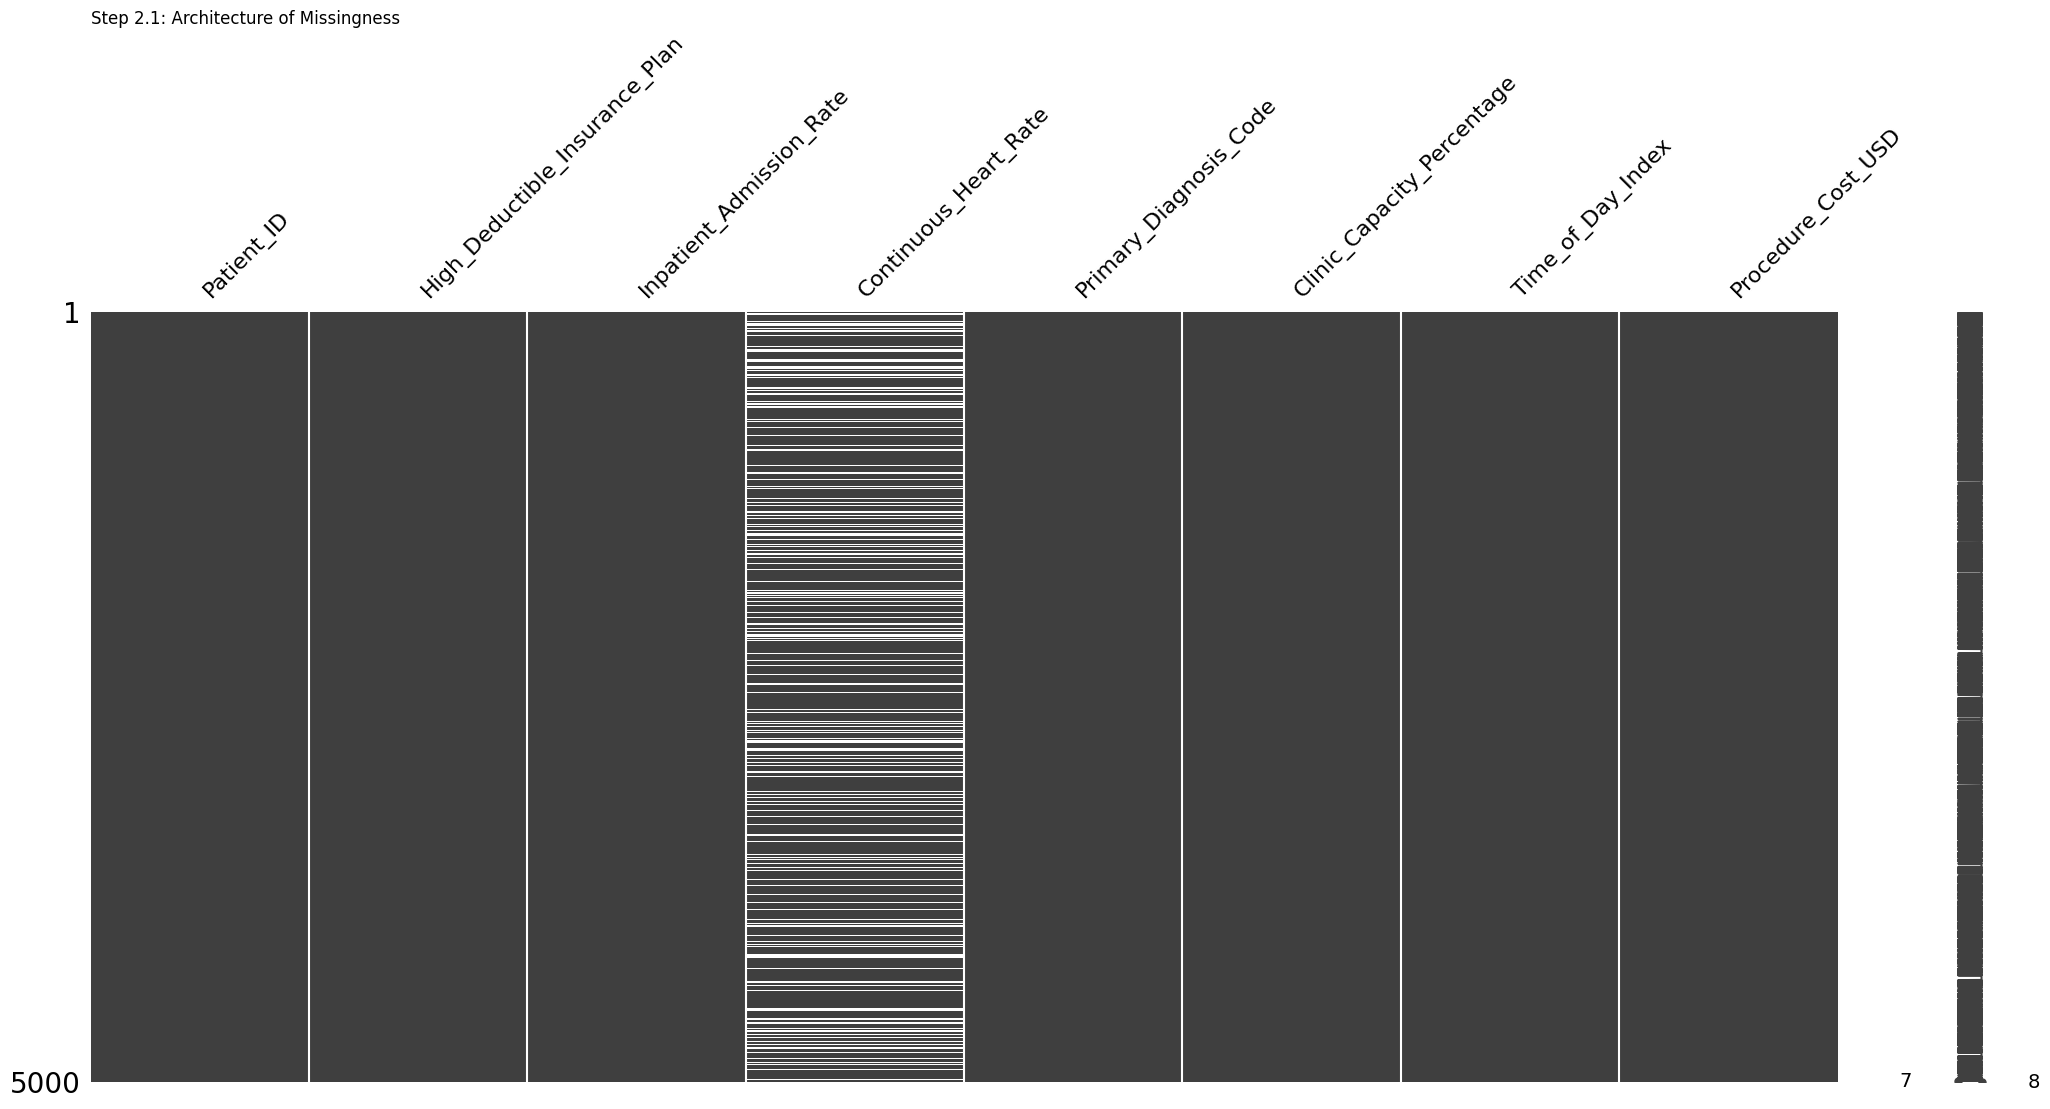

In [33]:
elemetry = pd.read_csv('https://raw.githubusercontent.com/zzzzzssyy/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Assignment%204/OmniCare_Telemetry_Data.csv')

msno.matrix(elemetry)
plt.title("Step 2.1: Architecture of Missingness", loc='left')
plt.show()

The missingness matrix shows that all variables are fully observed except Continuous_Heart_Rate, which contains significant gaps throughout the dataset. This pattern is not random — based on the scenario, low-income patients are less likely to transmit telemetry data due to cost. Since the probability of missingness depends on an unobserved factor (income), this is classified as Missing Not At Random (MNAR). Simple imputation methods such as mean imputation would introduce bias by ignoring these systematic differences.

Step 2.2: Escaping the Dummy Variable Trap

Using get_dummies on Primary_Diagnosis_Code creates 847 binary columns, one per unique diagnosis code. Since each patient belongs to exactly one category, every row sums to exactly 1. When an intercept is included in the OLS model, this creates perfect multicollinearity: one dummy column can always be expressed as a linear combination of the remaining 846. The design matrix becomes singular and cannot be inverted, making it impossible for OLS to compute valid coefficients.

Step 2.3: Target Encoding Implementation

In [41]:
encoder = ce.TargetEncoder(cols=['Primary_Diagnosis_Code'])

telemetry["Target_Encoded_Diagnosis"] = encoder.fit_transform(telemetry[["Primary_Diagnosis_Code"]],telemetry["Procedure_Cost_USD"])

print("First 5 rows of target-encoded data:")
telemetry[['Primary_Diagnosis_Code', 'Target_Encoded_Diagnosis']].head()

First 5 rows of target-encoded data:


,Primary_Diagnosis_Code,Target_Encoded_Diagnosis
0,J86.381,1707.697108
1,M29.789,1792.303198
2,E49.618,1730.334968
3,E66.244,1725.060944
4,J45.553,1801.821085


Instead of creating 847 dummy columns, TargetEncoder replaces each diagnosis code with the mean Procedure_Cost_USD for that category — compressing 847 binary columns into a single continuous feature. This eliminates the dummy variable trap while preserving the predictive signal of each diagnosis code.

Step 3.1: OLS Optimization via Patsy Formulas

In [46]:
model = smf.ols(
    formula="""Procedure_Cost_USD ~Target_Encoded_Diagnosis +Clinic_Capacity_Percentage +Time_of_Day_Index +Weight_kg + Height_cm +Systolic_BP + Diastolic_BP""",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                  0.242
Method:                 Least Squares   F-statistic:                     228.8
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          6.83e-296
Time:                        06:37:14   Log-Likelihood:                -36162.
No. Observations:                5000   AIC:                         7.234e+04
Df Residuals:                    4992   BIC:                         7.239e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The OLS model explains 24.3% of the variance in Procedure_Cost_USD (R² = 0.243). Target_Encoded_Diagnosis and Clinic_Capacity_Percentage are the strongest predictors, both statistically significant (p < 0.001). Physiological features (Weight_kg, Height_cm, Systolic_BP, Diastolic_BP) are not statistically significant, suggesting they contribute little to procedure cost prediction.

Step 3.2: Financial Loss Quantification (RMSE)

In [53]:
predictions = model.fittedvalues
model_rmse = rmse(df["Procedure_Cost_USD"],predictions)

print("RMSE:",round(model_rmse,2))

RMSE: 334.8


The model's predictions deviate from actual procedure costs by an average of $ 334.80. Given that a typical MRI costs around $ 1,200, this represents an error margin of over 27%. Such inaccuracy poses significant financial risk — the model could systematically overcharge patients, leading to regulatory violations, or undercharge, resulting in revenue losses. This makes the model unsafe for deployment in a real-world dynamic pricing system.

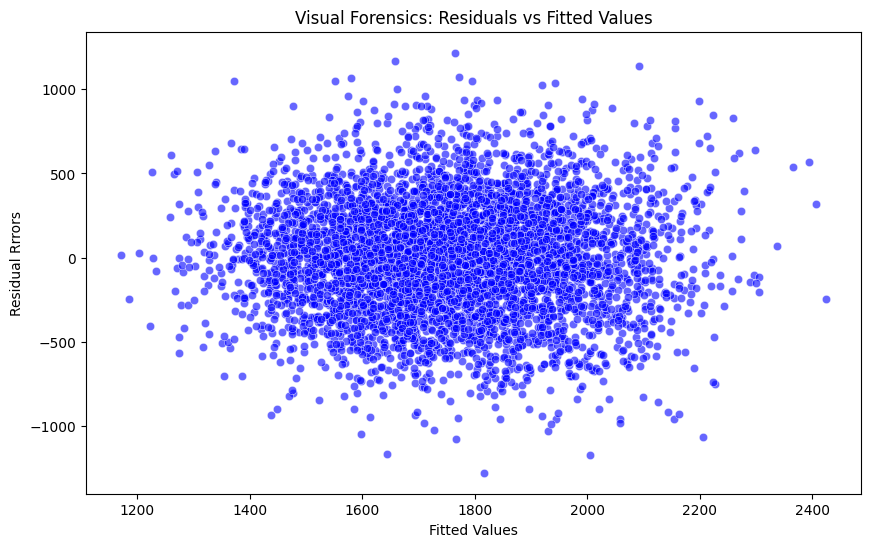

In [56]:
residuals = model.resid
fitted = model.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6, color='blue')
plt.title('Visual Forensics: Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residual Rrrors')
plt.show()

The residual plot shows residuals evenly distributed above and below zero across all fitted values, with no clear funnel or widening pattern. This suggests the variance of residuals is relatively constant, indicating no strong evidence of heteroscedasticity. The homoscedasticity assumption appears to hold for this model.

In [57]:
# Task 4.1: White's Lagrange Multiplier Test for Heteroscedasticity
from statsmodels.stats.diagnostic import het_white

residuals = model.resid
exog_vars = model.model.exog

lm_stat, lm_pval, f_stat, f_pval = het_white(residuals, exog_vars)

print("=" * 55)
print("   White's LM Test for Heteroscedasticity")
print("=" * 55)
print(f"  LM Statistic : {lm_stat:.4f}")
print(f"  LM p-value   : {lm_pval:.4f}")
print(f"  F-Statistic  : {f_stat:.4f}")
print(f"  F p-value    : {f_pval:.4f}")
print("-" * 55)

if lm_pval < 0.05:
    print("  RESULT  : Heteroscedasticity DETECTED")
    print("  MEANING : Consider HC3 robust standard errors")
else:
    print("  RESULT  : No strong evidence of heteroscedasticity")
    print("  MEANING : Homoscedasticity assumption holds")
print("=" * 55)

   White's LM Test for Heteroscedasticity
  LM Statistic : 186.4677
  LM p-value   : 0.0000
  F-Statistic  : 5.4942
  F p-value    : 0.0000
-------------------------------------------------------
  RESULT  : Heteroscedasticity DETECTED
  MEANING : Consider HC3 robust standard errors


White's LM Test returns a p-value of 0.0000, which is well below the 0.05 significance threshold. This confirms that heteroscedasticity is present — the variance of residuals is not constant across observations. This contradicts the visual inspection in Step 3.3, which appeared to show no clear pattern. The OLS standard errors are therefore unreliable, and HC3 robust standard errors or a WLS/GLS approach should be considered before drawing inference on healthcare pricing.